# Final Project: Part 1 - Numerical Solution of RLC Electrical Circuit

## Section 1: Introduction and Model Selection

#### Model selection

##### The real-world system that I have chosen is the RLC electrical circuit. Essentially, an RLC circuit works by transferring energy between two storage components, the capacitor and the inductor connected in parallel or series, with the resistor slowly bleeding energy away with each transfer. The energy transfers between these two sources back and forth, creating a harmonic oscillator for current. The purpose of an RLC circuit is to act as a filter or tuner by adjusting the values of the parameters. This allows the circuit to amplify signals at specific frequencies while supressing other, allowing them to isolate specific signals bathed in background noise.

#### The characteristic equation is in the form of:

$L \frac{d^2 q}{dt^2} + R \frac{dq}{dt} + \frac{q}{C} = V(t)$

#### The parameters represent:

$L$ = inductance (H).

##### This is a constant. In the equation, this parameter is measured in Henries and represents the inductor's ability to resist the changes in the current. When paired with the second derivative of charge, or the rate of change of current, it represents the voltage drop across the inductor, proportional to the rate of change of the current.

$R$ = resistance (Ω)

##### This is a constant. In the equation, this parameter is measured in Ohms and represents the energy lost via heat dissipation when the current crosses the resistor. When paired with the change of charge, or current, it represents the voltage drop across the resistor. This acts as the damper that causes the oscillations to converge to zero.

$C$ = capacitance (F)

##### This is a constant. In the equation, this parameter is measured in Farads and represents the ability of the capacitor to store charge. The term q/C neatly represents the voltage drop across the capacitor and comes directly from the equation C = Q/V for capacitance.

$q(t)$ = charge on capacitor (C)

##### This is a variable. In the equation, this represents the charge on the capacitor at a given point.

$V(t)$ = external voltage (V)

##### This is also known as the source voltage. This is the Electromotive force that is applied to the circuit via a power source such as a battery, and can be DC or AC. This input is what drives the system.

#### This equation can be broken down into a system of two first-order ODEs

##### Let y1 = q and y2 = current, or the derivative of charge. We get the following equations:

$$
\begin{aligned}
\frac{dy_1}{dt} &= y_2 \\
\frac{dy_2}{dt} &= \frac{1}{L} \left( V(t) - R y_2 - \frac{y_1}{C} \right)
\end{aligned}
$$

##### These equations will be what we use in our numerical methods.

## Section 2: Parameter Research and Justification

#### Physical Scenario

##### The specific physical scenario that will be modeled is a first-order band-pass crossover network, a type of audio filter, for a mid-range loudspeaker in audio engineering. When amplifying an acoustic instrument with sounds on lower frequencies and bass tones, such as those of an upright bass, these deep frequencies can distort when input through a smaller mid-range speaker. The same is true on the opposite end of the spectrum. To solve this, audio engineers implement the band-pass crossover network by creating an RLC circuit in a single series loop. The capacitor acts as the filter that blocks very low frequencies, while the inductor blocks very high frequencies, and the speaker outputs the remaining frequencies in the middle played at the same volume. To play the frequencies at the same volume, the system must be overdamped so that it does not resonate at the center frequency and amplify the charge when a frequency that matches this center frequency is input. The result is the band of frequencies pushing through the circuit with relatively equal current, resulting in an even, balanced volume.

#### The parameters for this specific application are defined in The Loudspeaker Design Cookbook by Vance Dickason (Audio Amateur Press, 7th Edition), specifically in chapter 7 of the book "Dividing Networks." (See Appendix)

##### The specific mid-range speaker that we will be examining has a standard resistance of 8 ohms, meaning that it only plays frequencies between 800 Hz and 4,500 Hz. (See Appendix) An example of such a speaker is the DS18 PRO-GM8SE Loudspeaker, which is commonly used throughout the United States. To isolate the midrange frequencies, the parameters of the circuit are listed below:

$R$ = 8.0 Ω

$L$ = 0.28 mH (Derived to remove frequencies above 4,500 Hz)

$C$ = 25 μF (Derived to remove frequencies below 800 Hz)

##### The inductance and capacitance are derived using formulas found from the standard acoustic engineering formulas documented in Vance Dickason's text mentioned above. Since the goal is to isolate a frequency of sounds between 800 Hz and 4,500 Hz, the parameters are calculated using the formulas below:

$$
\begin{aligned}
L &= \frac{R}{2\pi f_{high}} \\
C &= \frac{1}{2\pi f_{low} R}
\end{aligned}
$$

##### Where f_high is the maximum allowed frequency and f_low is the minimum allowed frequency, which are respectively 4,500 Hz and 800 Hz.

#### Determining Initial Conditions

##### In determining the initial conditions, we can examine the circuit's response to a sudden spike in voltage, which occurs when there is an aggressive input to the speaker from the instrument, such as a hard string pluck on the upright bass. To do this, we assume a 10 V DC step from the amplifier at t = 0. 

$V(0) = 10$

##### 10 V is a realistic value for a normal sound amplifier (such as a microphone) found in households. To verify that this is realistic, we can calculate the resultant power pushed through the speaker as a result of the 10 V. Since P = V^2/R, if the amplifier sends a 10 V signal into the 8 ohm speaker, the power is 12.5 Watts, which translates to a realistic volume for a brief, loud spike.

##### We choose the initial current to be 0 Amps at time = 0. This is because the inductor opposes any immediate change in current, even though the voltage has jumped up.

##### We choose the initial charge to be 0 Coulombs at time = 0. This is from assuming that the amplifier was completely quiet before the spike, meaning that there is 0 stored charge in the capacitor.

## Section 3: Numerical Methods Implementation

In [2]:
#general parameters
L = 0.00028 # Henries  
R = 8.0 # Ohms     
C = 0.000025  # Coulombs
V_step = 10.0 # Volts

### Implementation 1: Euler's Forward

In [3]:
import numpy as np
import matplotlib.pyplot as plt

#second ODE used in Euler's forward
def f(t, y1, y2):
    return (V_step - R * y2 - (1/C) * y1) / L

def Eulers_Forward(h):
    #time parameters
    t_start = 0   
    t_end = 0.0012 
    #initial conditions for varying parameters
    y1_0 = 0.0 #initial condition for charge
    y2_0 = 0.0 #initial condition for current.     
    
    #storage of time, charge, and current.
    #y1 is charge and y2 is current.
    t_values_eulers = np.arange(t_start, t_end + h, h)
    y1_values_eulers = np.zeros(len(t_values_eulers))
    y2_values_eulers = np.zeros(len(t_values_eulers))
    
    #initialize initial conditions
    y1_values_eulers[0] = y1_0
    y2_values_eulers[0] = y2_0
    
    # Euler's Method
    for i in range(1, len(t_values_eulers)):
        #values at time t
        t = t_values_eulers[i - 1]
        y1_t = y1_values_eulers[i - 1]
        y2_t = y2_values_eulers[i - 1]
        
        # Euler's forward
        y1_values_eulers[i] = y1_t + h * y2_t
        y2_values_eulers[i] = y2_t + h * f(t, y1_t, y2_t)

    return t_values_eulers, y1_values_eulers, y2_values_eulers

#### Implementation explanation:

##### To correctly implement Euler's forward method to represent the application, the function uses microsecond intervals and step sizes because the system operates at high frequencies. The method breaks up the original second-order ODE into two first-order ODEs. The system updates the first state, which is the charge, by looking at the old current. Then, the current is updated by calculating the second derivative using the second first-order ODE. The system does this for each step size until it reaches the end of the time range.

### Implementation 2: Runge-Kutta

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# This function defines the system of first-order ODEs for the system.
def f_rungekutta(t, y):
    dy1_dt = y[1] 
    dy2_dt = (V_step - R * y[1] - (1/C) * y[0]) / L 
    return np.array([dy1_dt, dy2_dt])

# This function uses the RK4 method to solve the ODE
def runge_kutta_4(f, h):
    #initialize time parameters
    y0 = np.array([0.0, 0.0]) 
    t0 = 0.0 
    tf = 0.0012 

    #initialize initial parameters
    t_values_rk4 = np.arange(t0, tf + h, h)
    y_values_rk4 = np.zeros((len(t_values_rk4), len(y0)))
    y_values_rk4[0] = y0
    
    #perform the RK4 iteration
    for i in range(1, len(t_values_rk4)):
        t = t_values_rk4[i - 1]
        y = y_values_rk4[i - 1] 
        
        k1 = f(t, y)
        k2 = f(t + h / 2, y + (h * k1 / 2))
        k3 = f(t + h / 2, y + (h * k2 / 2))
        k4 = f(t + h, y + (h * k3))
        
        #combine slopes with weights: (k1 + 2*k2 + 2*k3 + k4) / 6
        #update y based on the RK4 formula
        y_values_rk4[i] = y + h * ((k1 + 2 * k2 + 2 * k3 + k4) / 6)
        
    return t_values_rk4, y_values_rk4

#### Implementation explanation:

##### In this method implementation, Runge-Kutta is adapted to handle two first-order ODEs that represent the second-order ODE. To do this, we modify the function by passing y as a vector [charge, current]. This allows the method to calculate the states of both variables in parallel. Otherwise, the implementation matches standard textbook Runge-Kutta syntax, where it calculates the slope at the beginning (k1), takes two trial steps to check the slopes in the middle (k2, k3), and checks the slope at the very end (k4), before averaging them together and giving more weight to the midpoints.

## Section 4: Solutions and Comparisons

### Results for Euler's Forward

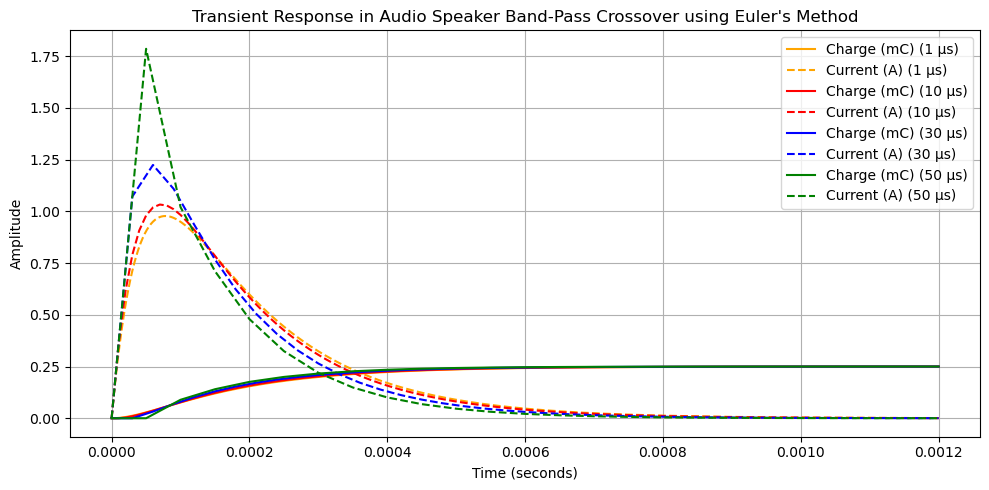

In [5]:
#initialize step sizes and colors
h_eulers = [0.000001, 0.000010, 0.000030, 0.000050]
colors = ['orange', 'red', 'blue', 'green']

#figure size
plt.figure(figsize=(10, 5))

for h, color in zip(h_eulers, colors):
    t_values, y1_values, y2_values = Eulers_Forward(h) 
    # Format h to microseconds for a cleaner legend label
    h_label = f"{h * 1e6:.0f} µs"
    # Charge (y) is multiplied by 1000 to be visible on the same axis as Current (v)
    plt.plot(t_values, y1_values * 1000, label=f'Charge (mC) ({h_label})', color=color)
    plt.plot(t_values, y2_values, label=f'Current (A) ({h_label})', linestyle='--', color=color)

plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.title('Transient Response in Audio Speaker Band-Pass Crossover using Euler\'s Method')
plt.legend() 
plt.grid(True)
plt.tight_layout()
plt.show()

### Results for Runge-Kutta

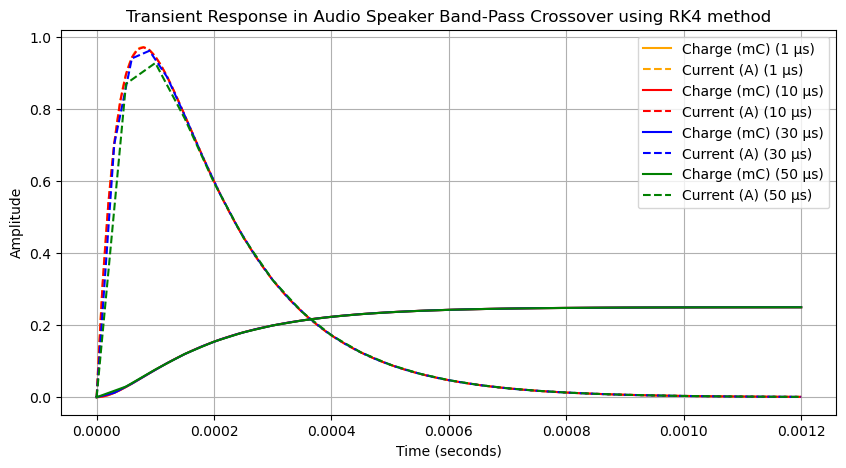

In [6]:
#initialize step sizes and colors
h_rk4 = [0.000001, 0.000010, 0.000030, 0.000050]
colors = ['orange', 'red', 'blue', 'green']

#figure size
plt.figure(figsize=(10, 5))

for h, color in zip(h_rk4, colors):
    # Run the RK4 solver
    t_values, y_values = runge_kutta_4(f_rungekutta, h)
    # Extract charge and current for plotting
    charge = y_values[:, 0]
    current = y_values[:, 1]
    h_label = f"{h * 1e6:.0f} µs"
    # Plot the results
    plt.plot(t_values, charge * 1000, label=f'Charge (mC) ({h_label})', color=color)
    plt.plot(t_values, current, label=f'Current (A) ({h_label})', linestyle='--', color=color)

plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.title('Transient Response in Audio Speaker Band-Pass Crossover using RK4 method')
plt.legend() 
plt.legend()
plt.grid(True)
plt.show()

#### Discussion of visual differences:

##### As the step sizes increase for each function, there is a noticeable difference between how it affects Euler's forward method and Runge-Kutta. Euler's forward method ends up becoming more and more unstable, with the slope overshooting as it fails to match the correct curve of the function. On the other hand, even with increasing step sizes, the Runge-Kutta method stays relatively stable visually.

##### Nonetheless, the solution models the RLC circuit interaction perfectly. Because the system is overdamped, the circuit ends up having two behaviors. Initially, the capacitor is empty and has no resistance. This results in the inductor fighting the current, resulting in the positive slope in the initial phases of the graph. As the current peaks, the inductor's magnetic field is stable, so it stops fighting the current. At the same time, the capacitor starts filling up and pushes back against the resistor, causing the current to decay back to zero. 


## Section 5: Stability Analysis

### a) Step size Investigation

#### Euler's Forward

Maximum stable step size
h_max = 0.000090 seconds (90.5 µs)
----------------------------------------
Step Size (h): 0.000050 s (50.0 µs)
Eigenvalues of function: [ 0.6769 -0.1055]
Status: Solution is Stable


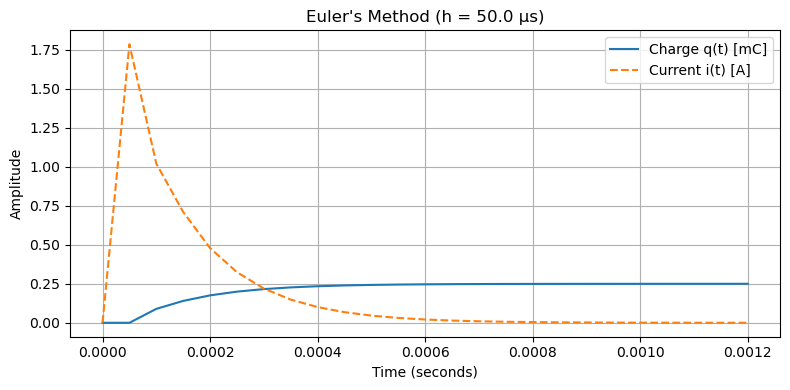

----------------------------------------
Step Size (h): 0.000090 s (90.5 µs)
Eigenvalues of function: [ 0.4156 -1.    ]
Status: Solution is Stable


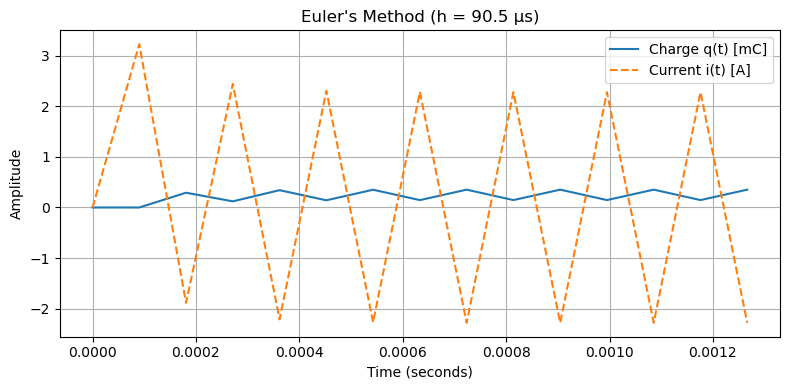

----------------------------------------
Step Size (h): 0.000095 s (95.5 µs)
Eigenvalues of function: [ 0.3833 -1.1106]
Status: Solution is not stable


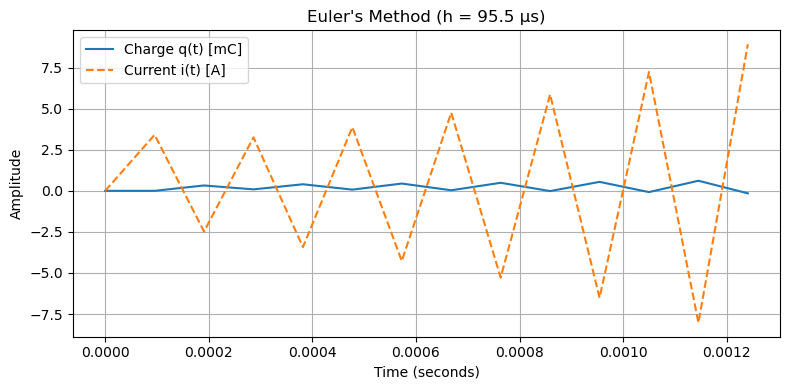

In [7]:
#Continuous-time system matrix A
A = np.array([[0, 1],[-1 / (L * C), -R / L]])

#finds the eigenvalues for calculating h_max
eigenvalues_A = np.linalg.eigvals(A)
#finds h_max using euler's stability: h_max = -2 * Re(lambda) / |lambda|^2
h_limits = -2 * np.real(eigenvalues_A) / (np.abs(eigenvalues_A)**2)
#finds the maximum stable step size
h_max = np.min(h_limits)
print(f"Maximum stable step size")
print(f"h_max = {h_max:.6f} seconds ({h_max * 1e6:.1f} µs)")

#step sizes to test
step_sizes = [0.000050, h_max, h_max + 0.000005]
t_end = 0.002

for h in step_sizes:
    #constructs coefficient matrix for Euler's method
    I = np.eye(2)
    M = I + h * A
    #computes eigenvalues to check stability
    eigenvalues = np.linalg.eigvals(M)
    
    print("-" * 40)
    print(f"Step Size (h): {h:.6f} s ({h*1e6:.1f} µs)")
    print(f"Eigenvalues of function: {np.round(eigenvalues, 4)}")

    #Checks if the eigenvalues are stable
    if np.all(np.abs(eigenvalues) <= 1.00000000): 
        print("Status: Solution is Stable")
    else:
        print("Status: Solution is not stable")

    #runs the Euler's method for each step size
    t_values, y1_values, y2_values = Eulers_Forward(h) 
    
    plt.figure(figsize=(8, 4))
    plt.plot(t_values, y1_values * 1000, label='Charge q(t) [mC]')
    plt.plot(t_values, y2_values, label='Current i(t) [A]', linestyle='--')
    plt.title(f"Euler's Method (h = {h*1e6:.1f} µs)")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

##### Discussion:

##### The maximum step size found in this method is h = 0.000090 s. The solution accuracy degrades with bigger and bigger step sizes as the algorithm overshoots the true curves. Numerical error is already being introduced, as evidenced in the 0.000050s time graph when compared to the earlier lower step sizes. When the step size is too large, the function becomes very unstable, with the current jumping up and down, becoming oscillatory by injecting artificial energy into the system. This destroys any useful data that the system might present. At h_max, the solution is critically stable, as the current oscillates violently between 2 A and -2 A. It no longer represents the circuit, but physically, it is still "stable" because energy is conserved.

#### Runge-Kutta

RK4 maximum stable h: 126.0 µs


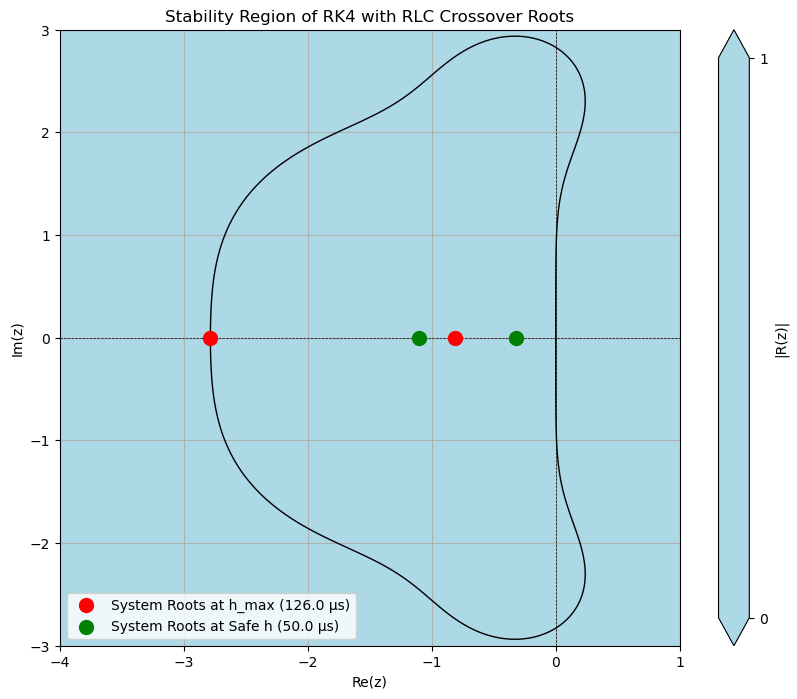

In [8]:
#continuous matrix A
A = np.array([[0, 1],[-1 / (L * C), -R / L]])

#continuous eigenvalues for the system
eigenvalues = np.linalg.eigvals(A)

#RK4 stability function
def rk4_stability_function(z):
    return 1 + z + (z**2) / 2 + (z**3) / 6 + (z**4) / 24

#finding h_max numerically by iterating bigger and bigger h values until the eigenvalues exceed 1
h_test = np.linspace(0, 0.0003, 10000)
h_max = 0
for h in h_test:
    z_test = h * eigenvalues
    R_vals = rk4_stability_function(z_test)
    if np.any(np.abs(R_vals) > 1.0):
        break
    h_max = h
print(f"RK4 maximum stable h: {h_max * 1e6:.1f} µs")

#generate plot of stability region
real_vals = np.linspace(-4, 1, 500) 
imag_vals = np.linspace(-3, 3, 500)
real, imag = np.meshgrid(real_vals, imag_vals)
z = real + 1j * imag

R_mag = rk4_stability_function(z)
magnitude = np.abs(R_mag)

plt.figure(figsize=(10, 8))
plt.contourf(real, imag, magnitude, levels=[0, 1], colors=['lightblue'], extend='both')
plt.colorbar(label='|R(z)|')
plt.contour(real, imag, magnitude, levels=[1], colors='black', linewidths=1)

#plotting specific eigenvalues at h_max
z_max = h_max * eigenvalues
plt.scatter(z_max.real, z_max.imag, color='red', s=100, zorder=5, label=f'System Roots at h_max ({h_max*1e6:.1f} µs)')

#plotting specific eigenvalues at h = 50 microseconds
h_safe = 0.000050
z_safe = h_safe * eigenvalues
plt.scatter(z_safe.real, z_safe.imag, color='green', s=100, zorder=5, label=f'System Roots at Safe h ({h_safe*1e6:.1f} µs)')

# Plot aesthetics
plt.title('Stability Region of RK4 with RLC Crossover Roots')
plt.xlabel('Re(z)')
plt.ylabel('Im(z)')
plt.legend(loc='lower left')
plt.grid(True)
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
plt.show()

##### Discussion:

##### The stability for the Runge-Kutta method can be derived from the numerical update formula. The code extracts the stability function R(z) and checks if the step size multiplied by the eigenvalue is equal to or lower than 1. In this case, the maximum step size h that is allowed before the function overruns the stability is 126 µs. This is greater than the step size limit for Euler's forward method. The graph also shows that at 50 µs, the system roots are well within the region of stability, so the curve is perfectly smooth and represents the true physical behavior of the overdamped speaker crossover. When the step size causes the method to become unstable, it behaves very similarly to an unstable Euler's forward method, where the function oscillates wildly out of control into physically impossible values within fractions of a millisecond.

### b) Error Quantification

#### Euler's Forward and Runge Kutta Comparison

Slope of Euler's Method: 1.1238 
Slope of RK4 Method: 4.1410


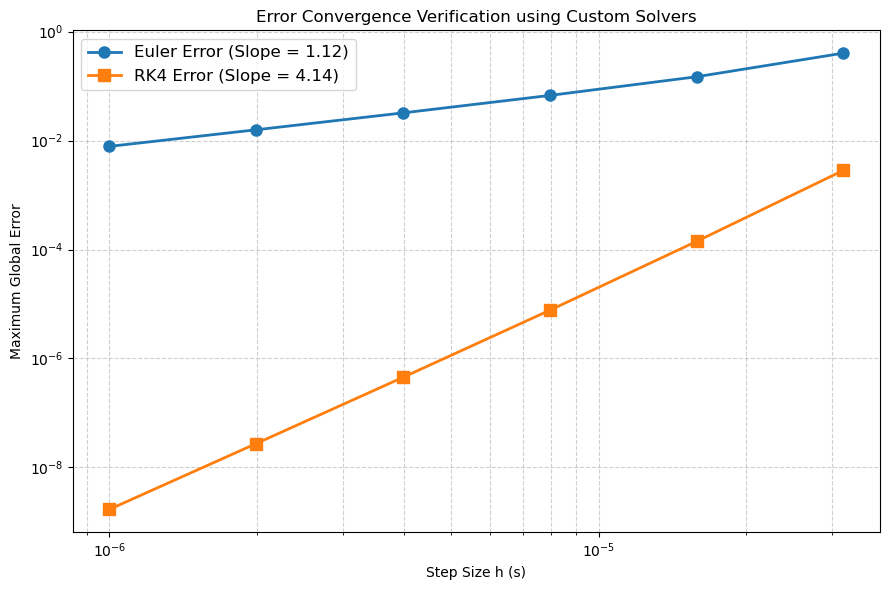

In [19]:
#Analytical solution for the RLC circuit that is being used (Gemini assisted)
def exact_current(t):
    #calculated Neper frequency
    alpha = R / (2 * L)
    #calculated natural resonant frequency
    w0_sq = 1 / (L * C)
    #discriminant
    beta = np.sqrt(alpha**2 - w0_sq)
    #characteristic roots used in solving the differential equation
    s1 = -alpha + beta
    s2 = -alpha - beta
    #Solution to the differential equation
    current_exact = (V_step / L) * (1 / (s1 - s2)) * (np.exp(s1 * t) - np.exp(s2 * t))
    return current_exact

#step size test values
h_test_values = np.logspace(-6, -4.5, 6) 

#maximum errors
euler_max_errors = []
rk4_max_errors = []

for h in h_test_values:
    #Euler's forward method
    t_euler, y1_euler, y2_euler = Eulers_Forward(h)
    
    #RK4 method
    t_rk4, y_rk4 = runge_kutta_4(f_rungekutta, h)
    
    #exact answers for specific time intervals
    exact_euler = exact_current(t_euler)
    exact_rk4 = exact_current(t_rk4)
    
    #maximum absolute error on the interval
    err_euler = np.max(np.abs(y2_euler - exact_euler))
    err_rk4 = np.max(np.abs(y_rk4[:, 1] - exact_rk4))

    #adds this maximum error to an array to be plotted
    euler_max_errors.append(err_euler)
    rk4_max_errors.append(err_rk4)

#convergence rate calculations
slope_euler, _ = np.polyfit(np.log(h_test_values), np.log(euler_max_errors), 1)
slope_rk4, _ = np.polyfit(np.log(h_test_values), np.log(rk4_max_errors), 1)

print(f"Slope of Euler's Method: {slope_euler:.4f} ")
print(f"Slope of RK4 Method: {slope_rk4:.4f}")

# 5. Generate Log-Log Plot
plt.figure(figsize=(9, 6))

#plotting error
plt.loglog(h_test_values, euler_max_errors, 'o-', linewidth=2, markersize=8, label=f"Euler Error (Slope = {slope_euler:.2f})")
plt.loglog(h_test_values, rk4_max_errors, 's-', linewidth=2, markersize=8, label=f"RK4 Error (Slope = {slope_rk4:.2f})")


plt.title("Error Convergence Verification using Custom Solvers")
plt.xlabel("Step Size h (s)")
plt.ylabel("Maximum Global Error")
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

##### Discussion:

##### The function calculates the analytical solution and compares it to the solution in each model to find the global error. It then plots the global error and calculates the slope of error vs. step size using a least squares linear regression. The resultant slopes are very close to the expected slopes of each method (Euler slope ~ 1 and RK4 slope ~ 4), which demonstrates that Euler's is a first-order accurate while RK4 is fourth-order accurate. Once again, the RK4 method is superior for minimizing global error in general.

### c) Physical Interpretation

#### Numerical instabilities and non-physical results

##### For this specific RLC circuit, the system is damped due to physical friction from the resistor, which constantly converts electrical energy into heat/sound and removes it from the circuit. Since there is no new energy entering the system after the initial 10 V spike, the current has to decay to zero. However, as evidenced by the step size analysis above, as the step size exceeds the stability limit, the mathematical error generated per step becomes larger than the amount of energy the resistor is burning off. This causes the solution to oscillate widely, growing larger with every step. Essentially, the model is injecting artificial energy into the system faster than the resistor can dissipate it, causing it to grow into infinity.

#### Stability and physical behavior of the system

##### According to Ohm's law, the maximum current that the circuit can support is 1.25 Amps. Looking at Euler's forward simulation when the solution became unstable at a large enough step size, we can see that the current exceeds 1.25 Amps at the peaks of the oscillation. This is physically impossible within the system and demonstrates that, at this step size, the model has stopped simulating the physical reality of the circuit and implies that the speaker is catching on fire and exploding due to exceeding its current limit by increasing orders of magnitude.

## Section 6: Conclusions

#### In general, the RK4 model performed better for the simulation of the RLC audio crossover. The RK4 model demonstrated a larger stability region, with the maximum allowable step size calculated to be around 126.0 µs, while the Euler's Forward model's step size limit is lower at 90.5 µs. Furthermore, as verified by the log-log error analysis, RK4 experienced significantly fewer errors at similar step sizes when compared to Euler's Forward. 

#### While Euler's Forward is more efficient computationally, this advantage is outweighed by its comparatively poor accuracy. In order to be accurate, Euler requires tiny step sizes, driving up the computational time needed. On the other hand, the RK4 model's accuracy allows the use of significantly larger step sizes, allowing for less total computational time even though it requires 4 function evaluations at every step.

#### For simulating dynamical systems such as RLC circuits and analog filters, RK4 is the recommended model, while Euler's forward should just be used to sanity check results. Additionally, this investigation reinforced the idea that numerical solvers are inherently blind to physics. If a step size happens to go over the stability limit, the system will artificially inject energy into the system, violating known physics laws and producing unrealistic results. Engineers must find this delicate balance between stability, accuracy, and computational cost before proceeding with scaling or further developing their numerical solvers.
 

## Appendix: Citations + AI usage

#### Textbook Used in finding the parameters:
#### Dickason, V., & Raichel, D. R. (1999). The Loudspeaker Design Cookbook, 5th Edition. The Journal of the Acoustical Society of America, 106, 2329-2330. https://doi.org/10.1121/1.428228

#### AI Usage:
#### In section 2, Gemini AI was used to find a source that provided realistic initial conditions and parameters for an audio filter.
#### In section 3, Gemini AI was used to clean up and verify that the solutions provided by the code were correct.
#### In section 4, Gemini AI was used to help modify the plots to make them user-friendly and readable
#### In section 5, Gemini AI was used to construct a solution for finding the eigenvalues of the Euler's Forward method and displaying the maximum alloted step size. Gemini AI was also used to make the graph used in the RK4 stability analysis more readable. Finally, Gemini AI was used to derive an expression for the analytical solution to the RLC circuit, as well as the implementation of finding the slopes to verify convergence and error analysis/plotting.